In [1]:
import pandas as pd
import xarray as xr
import numpy as np
import glob as glob

import matplotlib.pyplot as plt
import matplotlib.animation as animation

from matplotlib.ticker import FormatStrFormatter
from scipy.interpolate import interp1d

# Aim: Plot transect (depth versus Y)
- Define transect first 
- Extract data at transect and plot 

# Load bathymetry

In [16]:
path_bathy = '../../../data/lake_zug/model/'
fname_bathy = 'fine_bathy.nc'
bathy = xr.open_dataset(path_bathy + fname_bathy).depth
bathy = bathy.rename({'xsc':'X','ysc':'Y'})

# Load MITgcm data 

In [5]:
def load_data(run, output, var):

    # Change your path accordingly 
    path_in = "../../../data/lake_zug/{}/{}/".format(run,output)
    fname_data = glob.glob(path_in + var + "*.nc")

    data = xr.open_mfdataset(fname_data, chunks={'X':8,'Y':16}).squeeze()
    data = data.sortby('T').drop_duplicates(dim='T')

    return (data)

In [6]:
run = 'model'
output = 'out3'

u = load_data(run, output, "u").U
v = load_data(run, output, "v").V
theta = load_data(run,output,"theta").Temp

In [7]:
u

<xarray.DataArray 'U' (T: 721, Z: 200, Y: 120, X: 54)> Size: 4GB
dask.array<getitem, shape=(721, 200, 120, 54), dtype=float32, chunksize=(721, 200, 16, 8), chunktype=numpy.ndarray>
Coordinates:
  * T        (T) datetime64[ns] 6kB 2026-01-30 ... 2026-03-01
    iter     (T) int32 3kB dask.array<chunksize=(721,), meta=np.ndarray>
  * X        (X) float64 432B 60.0 180.0 300.0 ... 6.18e+03 6.3e+03 6.42e+03
  * Y        (Y) float64 960B 60.0 180.0 300.0 ... 1.41e+04 1.422e+04 1.434e+04
  * Z        (Z) float64 2kB -0.25 -0.7525 -1.26 -1.772 ... -196.3 -197.8 -199.2
Attributes:
    units:    m/s

# Define transect 
- Transect is defined by manually selecting coordinates 

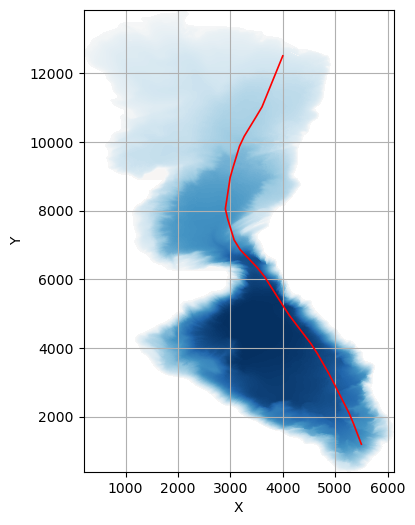

In [17]:
# manually extract transect 
xx = np.array((4000,3600,3200,3000,2900,3100,3600,4100,4600,4900,5300, 5500))
yy = np.array((12500,11000,10000,9000,8000,7000,6200,5000,4000,3200,2000, 1200))

#reverse order so that transect starts in the south
xx = np.flip(xx)
yy = np.flip(yy)

# Define fine-resolution distance along the talweg
dist = np.insert(np.sqrt(np.diff(xx)**2 + np.diff(yy)**2).cumsum(), 0, 0)

# Create piecewise interpolation functions
f_x = interp1d(dist, xx, kind='linear')  # Interpolate X
f_y = interp1d(dist, yy, kind='linear')  # Interpolate Y

# Generate new interpolated points
fine_dist = np.linspace(dist.min(), dist.max(), 40)  # Adjust resolution as needed
xx_trans = f_x(fine_dist)
yy_trans = f_y(fine_dist)

# Plot
fig, ax = plt.subplots(figsize=(4, 6))
bathy.plot(add_colorbar=False)
#ax.scatter(xx, yy, color='red', label='Original Points')
#ax.scatter(xx_sel, yy_sel, color='blue', label='Piecewise Interpolation',marker='x')
plt.plot(xx_trans, yy_trans, 'r-',linewidth=1.2)
plt.grid()

# Extract data along transect 

In [18]:
def extract_along_xy(data, xx, yy, x_dim="X", y_dim="Y", dist_dim="dist"):
    """
    Extract an xarray DataArray or Dataset along selected x/y coordinates.
    ----------
    data : xr.DataArray or xr.Dataset
        Input xarray object with horizontal coordinates x_dim and y_dim.
    xx, yy : array-like
        Coordinates of the transect/path points.
    x_dim, y_dim : str
        Names of the x and y coordinates in data.
    dist_dim : str
        Name of the new along-transect distance dimension.

    Returns
    -------
    data_trans : xr.DataArray or xr.Dataset
        Interpolated data along the path, with dimension `dist_dim`.
    """

    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if xx.shape != yy.shape:
        raise ValueError("xx and yy must have the same shape.")

    # Coordinates used for interpolation
    x_points = xr.DataArray(xx, dims=dist_dim)
    y_points = xr.DataArray(yy, dims=dist_dim)

    # Interpolate along the selected path
    data_trans = data.interp(
        {
            x_dim: x_points,
            y_dim: y_points,
        }
    )

    # Compute cumulative distance along the path
    dx = np.diff(xx)
    dy = np.diff(yy)
    dist = np.insert(np.sqrt(dx**2 + dy**2).cumsum(), 0, 0)

    # Replace the transect index coordinate with distance
    data_trans = data_trans.assign_coords({dist_dim: dist})

    return data_trans

In [19]:
v_trans = extract_along_xy(v,xx_trans,yy_trans)
theta_trans = extract_along_xy(theta,xx_trans,yy_trans)

# Plot transect
- Transect at selected time 

Text(0.5, 1.0, '2026-02-20T20:00:00.00')

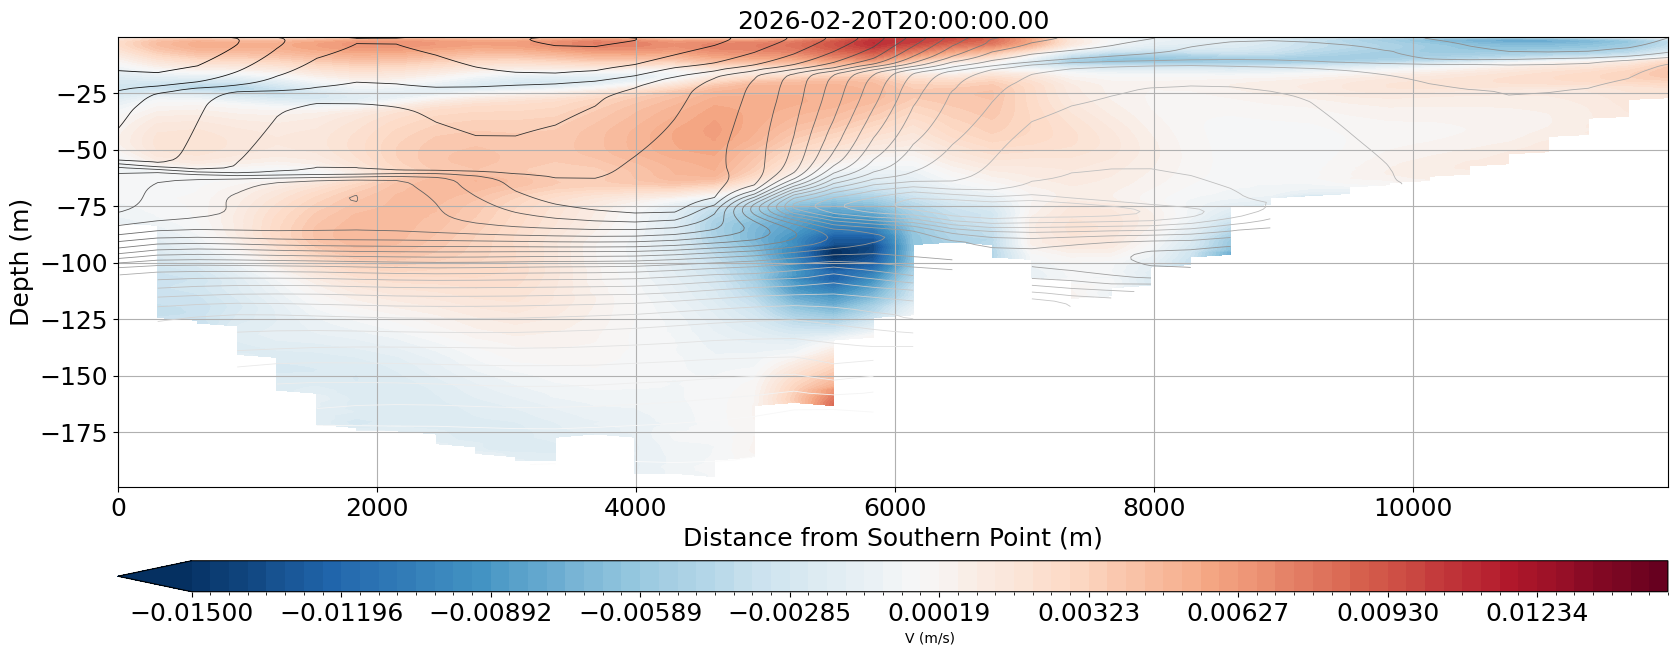

In [20]:
lsize = 18
vmin = -0.015
vmax = -1 * vmin
tt_sel = "2026-02-20T20:00:00.00"

# Plot Transect (Distance vs Depth)
fig, ax = plt.subplots(figsize=(20, 8))

contour = v_trans.sel(T=tt_sel).plot.contourf(levels=80,x='dist',y='Z', cmap='RdBu_r',vmin=vmin,vmax=vmax, add_colorbar=False)
theta_trans.sel(T=tt_sel).plot.contour(levels=40,cmap='Greys',linewidths=0.6, linestyles='-')

cbar = fig.colorbar(contour, ax=ax, orientation='horizontal', pad=0.12, aspect=50)
cbar.set_label("V (m/s)")


ax.tick_params(axis='both', labelsize=lsize)  # X and Y axis tick labels
cbar.ax.tick_params(labelsize=lsize)  # Colorbar tick labels


ax.grid()
ax.set_xlabel("Distance from Southern Point (m)",fontsize=lsize)
ax.set_ylabel("Depth (m)",fontsize=lsize)
ax.set_title("{}".format(tt_sel),fontsize=lsize)